## rSVD versus rSVDAdjoint

In this notebook I compare the computational time of the rSVD algorithms versus using the rSVDAdjoint algorithm.
The rSVDAdjoint algorithm approximates $K^* \approx K^*_k = \tilde U \tilde \Sigma \tilde V^T$, and then $K$ can be approximated via 
$$
K \approx M_\partial^{-1} (K_k^*)^T M = M_\partial^{-1} \tilde V \tilde \Sigma \tilde U^T M
$$
To recover the SVD of $K$, let $F = M_\partial^{-1} \tilde V$ and $G = M \tilde U^T$, meaning $K \approx F \tilde \Sigma G^T$. Orthogonalization of $F$ and $G$ is done by QR factorization, $Q_F R_F = F$ and $Q_G R_G = G$, so that $K \approx Q_F (R_F \tilde \Sigma R_G^T) Q_G$, and the SVD $R_F \tilde \Sigma R_G^T = \hat U \Sigma \hat V^T$ gives $K \approx (Q_F \hat U) \Sigma (\hat V^T Q_G^T)$, with $U = Q_F \hat U$ and $V = Q_G \hat V$ yielding the SVD $K \approx U \Sigma V^T$.

---

In [5]:
import numpy as np
import pandas as pd
from time import time
from algorithms.rsvd_solvers import MatrixFreeRSVD, MatrixFreeRSVDAdjoint
from fenics import FunctionSpace, UnitSquareMesh, plot, Function
from utils.problem_setup import TestProblemsSetup
from utils.solvers import fast_svd_solver
from utils.utils import progress_bar, disk_cache
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

RESULTS_FOLDER = '../../results/computational_time_adjoint_rsvd'
PROBLEMS = TestProblemsSetup(n=64).get_test_problems()
SEED = 15


In [6]:
@disk_cache(RESULTS_FOLDER)
def experiment(N_range, k, repeat):

    record = []
    n_steps, step = len(N_range) * repeat, 1
    for N in N_range:
        n = round(np.sqrt(N))
        V_h = FunctionSpace(UnitSquareMesh(n, n), 'CG', 1)

        for _ in range(repeat):
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1
            
            result = {'N': N}

            # Approximate K
            t = time()
            rsvd = MatrixFreeRSVD(V_h)
            rsvd.solve(k=k)
            result['rsvd'] = time() - t

            # Approximate K*
            t = time()
            rsvd_adj = MatrixFreeRSVDAdjoint(V_h)
            rsvd_adj.solve(k=k)
            result['rsvd_adj'] = time() - t 

            # Recover K from K*
            t = time()
            rsvd_adj.recover_K()
            result['recovery'] = time() - t

            record.append(result)

    return pd.DataFrame(record)


In [68]:
# Repeat = 1 ~ 7 min
N_range = np.linspace(4_000, 100_000, 11, dtype=int)
repeat = 1
params = [
    {'N_range': N_range, 'k': 10, 'repeat': repeat},
    {'N_range': N_range, 'k': 50, 'repeat': repeat},
    {'N_range': N_range, 'k': 200, 'repeat': repeat},
]
results = [{'params': p, 'df': experiment(**p)} for p in params]

[##############################] 11/11 [N=100,000]
[##############################] 11/11 [N=100,000]
[##############################] 11/11 [N=100,000]


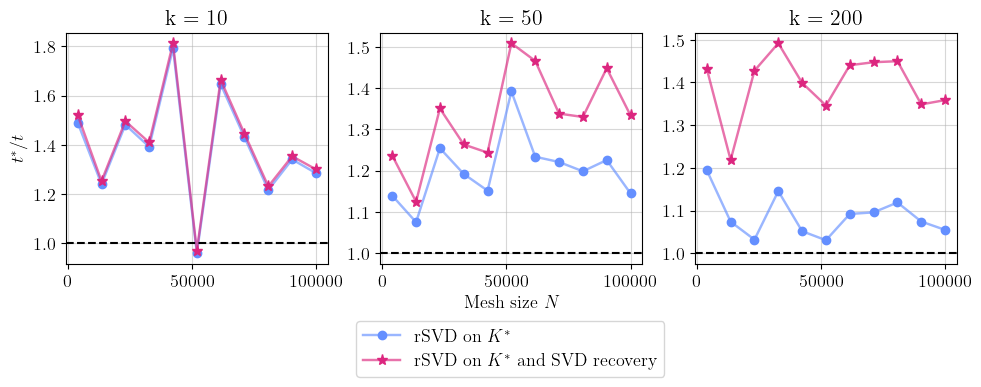

In [76]:
from utils.colors import C2, M, MS
from matplotlib.lines import Line2D
from utils.plotting import save_plot


def plot_results(results, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3), sharex=False)

    for ax, result in zip(axes.T.flat, results):
        params = result['params']
        df = result['df'].groupby('N').agg('median').reset_index()
        
        ax.plot(df.N, df['rsvd_adj'] / df['rsvd'], c=C2[0], lw=1.75, alpha=.65)
        ax.plot(df.N, df['rsvd_adj'] / df['rsvd'], M[0], ms=MS[0], c=C2[0], lw=2,)

        ax.plot(df.N, (df['rsvd_adj'] + df['recovery']) / df['rsvd'], c=C2[1], lw=1.75, alpha=.65)
        ax.plot(df.N, (df['rsvd_adj'] + df['recovery']) / df['rsvd'], M[1], ms=MS[1], c=C2[1], lw=2)

        ax.axhline(1.0, c='black', ls='--')
        
        ax.set_title(f"k = {params['k']}")
        ax.grid(True, alpha=0.5)

    # Custom labels
    handles, labs = [], ['rSVD on $K^*$', 'rSVD on $K^*$ and SVD recovery']
    for i in range(2):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=1.75, alpha=0.65)
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))


    axes[0].set_ylabel("$t^* / t$")
    axes[1].set_xlabel('Mesh size $N$')
    axes[1].legend(handles=handles, labels=labs, bbox_to_anchor=(1.118, -0.21), ncols=1)
    fig.subplots_adjust(wspace=0.2)

    save_plot(fig_name)
    plt.show()


plot_results(results, 'computational_time_of_adjoint_rsvd')